# 더블레이어 IPM 4인자 CCF 50점 분석

## 설계 정의

- 안쪽 자석: 기준 길이, 기준 총 두께의 1/2
- 바깥 자석: 안쪽 자석 대비 길이 80%, 두께 80%
- 레이어 수직 gap: 설계변수
- TIPGAP: 0.608 mm 고정
- 자석군 반경 이동: 1.0 mm 고정
- 자석 사용량: 기존 싱글레이어의 **82%**

## 먼저 보는 결론

- **리플 최소:** Run 33 — 37.60 Nm / 3.13 Nm
- **저리플 균형:** Run 22 — 42.39 Nm / 3.43 Nm
- **종합 균형:** Run 19 — 46.00 Nm / 5.33 Nm
- **평균토크 최대:** Run 15 — 49.06 Nm / 7.89 Nm

자석을 18% 줄였음에도 Run 19는 싱글레이어 균형점 Run 49의 평균토크를 거의 유지했다.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore", message="Glyph .* missing")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5.5)
pd.options.display.float_format = "{:.4f}".format

ROOT = Path.cwd()
if not (ROOT / "double_layer_ccf_50_results").exists():
    ROOT = Path("C:/Users/139/Documents/pyFEMM 2")

DOUBLE_DIR = ROOT / "double_layer_ccf_50_results"
DOUBLE_CSV = DOUBLE_DIR / "double_layer_ccf_summary.csv"
SINGLE_CSV = ROOT / "doe_axis_shortedge_results" / "axis_shortedge_ccf_summary.csv"

df = pd.read_csv(DOUBLE_CSV)
single = pd.read_csv(SINGLE_CSV)
factors = [
    "total_thickness_mm",
    "inner_length_mm",
    "v_angle_deg",
    "layer_normal_gap_mm",
]
factor_labels = ["Total thickness", "Inner length", "V angle", "Layer gap"]
mean_col = "loaded_torque_mean_Nm"
ripple_col = "loaded_torque_pkpk_Nm"
ripple_pct_col = "loaded_torque_ripple_pct"

print(f"Double-layer designs: {len(df)}")
print(f"Magnet usage ratio: {df.magnet_area_ratio_vs_single.iloc[0]:.0%}")
print(f"Operating points: {len(df)} × {int(df.completed_points.iloc[0])}")

Double-layer designs: 50
Magnet usage ratio: 82%
Operating points: 50 × 15


## 1. 결과 완전성 검사

In [2]:
checks = []
for run in df.run.astype(int):
    path = DOUBLE_DIR / f"run_{run:03d}" / "axis_shortedge_loaded_sweep.csv"
    rows = len(pd.read_csv(path)) if path.exists() else 0
    checks.append((run, rows, "OK" if rows == 15 else "CHECK"))
checks = pd.DataFrame(checks, columns=["run", "sweep_rows", "status"])
display(checks.status.value_counts().to_frame("design_count"))
assert len(df) == 50 and (checks.sweep_rows == 15).all()
print("검증 통과: 50개 설계 × 15개 각도 = 750개 FEMM 운전점")

,design_count
status,
OK,50


검증 통과: 50개 설계 × 15개 각도 = 750개 FEMM 운전점


## 2. 성능 순위

In [3]:
show = factors + [mean_col, ripple_col, ripple_pct_col]
rename = {
    "total_thickness_mm": "Total thickness [mm]",
    "inner_length_mm": "Inner length [mm]",
    "v_angle_deg": "V angle [deg]",
    "layer_normal_gap_mm": "Layer gap [mm]",
    mean_col: "Mean torque [Nm]",
    ripple_col: "Ripple pk-pk [Nm]",
    ripple_pct_col: "Ripple [%]",
}
print("평균토크 상위 10개")
display(df.set_index("run").nlargest(10, mean_col)[show].rename(columns=rename))
print("절대 리플 하위 10개")
display(df.set_index("run").nsmallest(10, ripple_col)[show].rename(columns=rename))

평균토크 상위 10개


,Total thickness [mm],Inner length [mm],V angle [deg],Layer gap [mm],Mean torque [Nm],Ripple pk-pk [Nm],Ripple [%]
run,,,,,,,
15,4.4068,16.6981,71.2442,1.7026,49.0608,7.8877,16.0774
32,5.4089,16.0193,74.7938,1.6338,48.7219,7.8825,16.1786
28,4.6313,16.3868,71.6842,1.2395,48.2788,7.9136,16.3914
6,4.2391,16.7226,72.5807,1.0879,47.4372,7.2498,15.2829
45,5.0469,16.3779,77.8247,1.6914,47.3449,7.1555,15.1136
16,4.8002,15.9746,74.9419,1.1781,46.3893,7.3655,15.8777
48,5.3829,15.7118,76.1231,0.5991,46.3351,7.1666,15.4670
2,4.8746,15.9136,74.8695,0.7418,46.1057,7.3115,15.8580
19,5.1340,16.6876,81.2202,1.9593,46.0003,5.3300,11.5870


절대 리플 하위 10개


,Total thickness [mm],Inner length [mm],V angle [deg],Layer gap [mm],Mean torque [Nm],Ripple pk-pk [Nm],Ripple [%]
run,,,,,,,
33,3.5758,16.2042,88.5312,0.6281,37.5971,3.1341,8.3359
22,4.8976,16.3704,86.7644,0.6040,42.3918,3.4264,8.0828
7,4.3884,16.0551,88.6059,0.9354,39.0915,3.5256,9.0188
41,5.0962,16.3647,85.5745,1.1019,42.4404,3.6743,8.6575
37,4.2098,15.8851,86.5357,0.7851,39.6180,3.7935,9.5752
44,4.5903,15.7191,87.1180,0.7091,40.0574,4.0696,10.1595
36,3.8965,15.1086,89.7585,1.3491,34.3023,4.0934,11.9334
40,4.4461,15.7506,86.1179,1.5223,39.0738,4.1193,10.5424
38,4.5734,16.0178,84.0622,1.1762,41.5496,4.2503,10.2294


## 3. 더블레이어 파레토 프론트

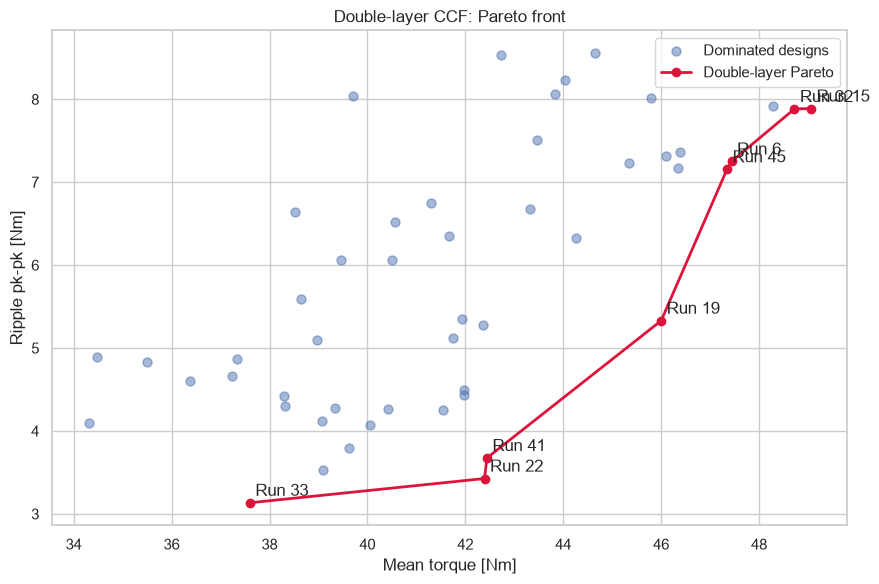

,Total thickness [mm],Inner length [mm],V angle [deg],Layer gap [mm],Mean torque [Nm],Ripple pk-pk [Nm],Ripple [%]
run,,,,,,,
33,3.5758,16.2042,88.5312,0.6281,37.5971,3.1341,8.3359
22,4.8976,16.3704,86.7644,0.6040,42.3918,3.4264,8.0828
41,5.0962,16.3647,85.5745,1.1019,42.4404,3.6743,8.6575
19,5.1340,16.6876,81.2202,1.9593,46.0003,5.3300,11.5870
45,5.0469,16.3779,77.8247,1.6914,47.3449,7.1555,15.1136
6,4.2391,16.7226,72.5807,1.0879,47.4372,7.2498,15.2829
32,5.4089,16.0193,74.7938,1.6338,48.7219,7.8825,16.1786
15,4.4068,16.6981,71.2442,1.7026,49.0608,7.8877,16.0774


In [4]:
def pareto_mask(frame, mean=mean_col, ripple=ripple_col):
    m = frame[mean].to_numpy()
    r = frame[ripple].to_numpy()
    return np.array([
        not np.any((m >= m[i]) & (r <= r[i]) & ((m > m[i]) | (r < r[i])))
        for i in range(len(frame))
    ])

df["pareto"] = pareto_mask(df)
front = df[df.pareto].sort_values(mean_col)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df.loc[~df.pareto, mean_col], df.loc[~df.pareto, ripple_col],
           s=42, alpha=0.5, label="Dominated designs")
ax.plot(front[mean_col], front[ripple_col], "-o", color="crimson",
        lw=2, label="Double-layer Pareto")
for _, row in front.iterrows():
    ax.annotate(f"Run {int(row.run)}", (row[mean_col], row[ripple_col]),
                xytext=(4, 5), textcoords="offset points")
ax.set(xlabel="Mean torque [Nm]", ylabel="Ripple pk-pk [Nm]",
       title="Double-layer CCF: Pareto front")
ax.legend()
plt.tight_layout()
plt.show()
display(front.set_index("run")[show].rename(columns=rename))

## 4. 싱글레이어와 직접 비교

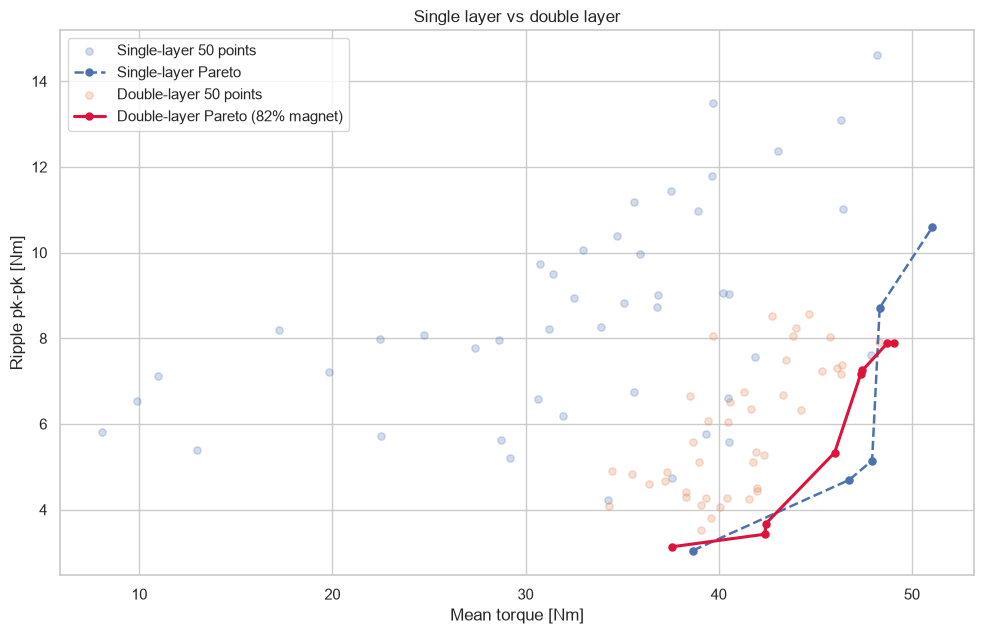

,Magnet ratio,Mean torque [Nm],Ripple [Nm]
Design,,,
Single Run 49,1.0000,46.7562,4.6941
Double Run 22,0.8200,42.3918,3.4264
Double Run 19,0.8200,46.0003,5.3300
Single max,1.0000,51.0658,10.5968
Double Run 15,0.8200,49.0608,7.8877


In [5]:
single["pareto"] = pareto_mask(single)
single_front = single[single.pareto].sort_values(mean_col)

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(single[mean_col], single[ripple_col], s=28, alpha=0.25,
           label="Single-layer 50 points")
ax.plot(single_front[mean_col], single_front[ripple_col], "--o",
        lw=1.8, ms=5, label="Single-layer Pareto")
ax.scatter(df[mean_col], df[ripple_col], s=28, alpha=0.25,
           label="Double-layer 50 points")
ax.plot(front[mean_col], front[ripple_col], "-o", color="crimson",
        lw=2.2, ms=5, label="Double-layer Pareto (82% magnet)")
ax.set(xlabel="Mean torque [Nm]", ylabel="Ripple pk-pk [Nm]",
       title="Single layer vs double layer")
ax.legend()
plt.tight_layout()
plt.show()

single_balance = single.loc[single.run == 49].iloc[0]
single_max = single.loc[single[mean_col].idxmax()]
comparison = pd.DataFrame([
    ["Single Run 49", 1.00, single_balance[mean_col], single_balance[ripple_col]],
    ["Double Run 22", 0.82, df.loc[df.run == 22, mean_col].iloc[0],
     df.loc[df.run == 22, ripple_col].iloc[0]],
    ["Double Run 19", 0.82, df.loc[df.run == 19, mean_col].iloc[0],
     df.loc[df.run == 19, ripple_col].iloc[0]],
    ["Single max", 1.00, single_max[mean_col], single_max[ripple_col]],
    ["Double Run 15", 0.82, df.loc[df.run == 15, mean_col].iloc[0],
     df.loc[df.run == 15, ripple_col].iloc[0]],
], columns=["Design", "Magnet ratio", "Mean torque [Nm]", "Ripple [Nm]"])
display(comparison.set_index("Design"))

### 비교 해석

- **Run 22:** 싱글레이어 Run 49보다 평균토크는 낮지만 자석을 18% 줄이면서 리플도 크게 감소한다.
- **Run 19:** 자석을 18% 줄이고도 싱글레이어 Run 49와 비슷한 평균토크를 유지한다. 리플은 약간 증가한다.
- **Run 15:** 싱글레이어 최대토크보다 평균토크가 약 4% 낮지만 리플은 더 작고 자석은 18% 적다.

따라서 더블레이어의 장점은 절대 최대토크 상승보다 **자석 사용량 대비 성능**에서 나타난다.

## 5. 상관관계와 2차 반응표면 민감도

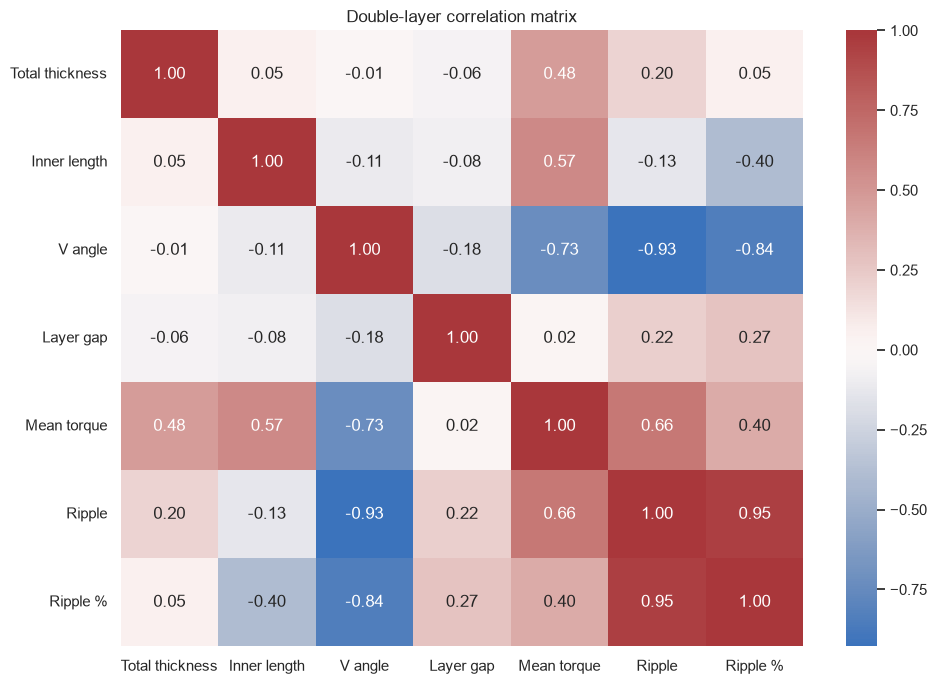

In [6]:
corr = df[factors + [mean_col, ripple_col, ripple_pct_col]].corr()
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            xticklabels=factor_labels + ["Mean torque", "Ripple", "Ripple %"],
            yticklabels=factor_labels + ["Mean torque", "Ripple", "Ripple %"],
            ax=ax)
ax.set_title("Double-layer correlation matrix")
plt.tight_layout()
plt.show()

,Mean torque model,Ripple model
Training R2,0.9990,0.9898
CV R2,0.9965,0.9789
Training RMSE,0.1154,0.1601
CV RMSE,0.2167,0.2299


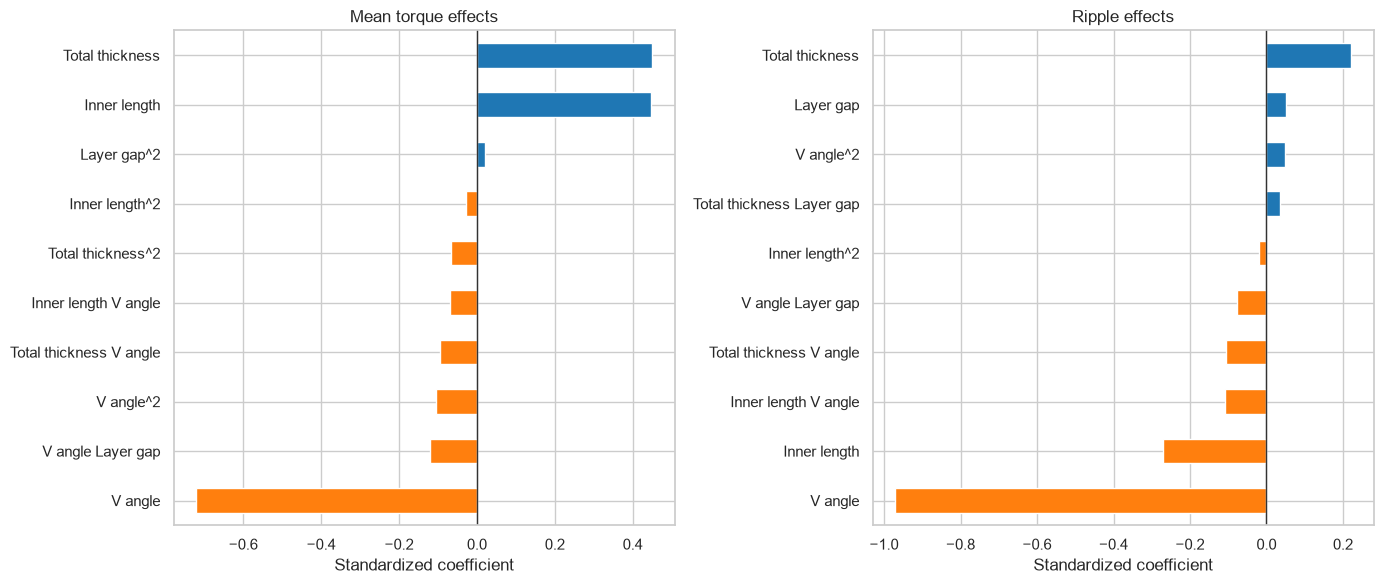

In [7]:
X = df[factors]
cv = KFold(n_splits=5, shuffle=True, random_state=123)

def fit_quadratic(target):
    model = Pipeline([
        ("scale_x", StandardScaler()),
        ("poly", PolynomialFeatures(2, include_bias=False)),
        ("reg", LinearRegression()),
    ])
    wrapped = TransformedTargetRegressor(
        regressor=model, transformer=StandardScaler()
    )
    y = df[target].to_numpy()
    pred_cv = cross_val_predict(wrapped, X, y, cv=cv)
    wrapped.fit(X, y)
    fitted = wrapped.predict(X)
    inner = wrapped.regressor_
    terms = inner.named_steps["poly"].get_feature_names_out(factor_labels)
    effects = pd.Series(
        inner.named_steps["reg"].coef_, index=terms
    ).sort_values(key=np.abs, ascending=False)
    metrics = {
        "Training R2": r2_score(y, fitted),
        "CV R2": r2_score(y, pred_cv),
        "Training RMSE": root_mean_squared_error(y, fitted),
        "CV RMSE": root_mean_squared_error(y, pred_cv),
    }
    return metrics, effects

mean_metrics, mean_effects = fit_quadratic(mean_col)
ripple_metrics, ripple_effects = fit_quadratic(ripple_col)
display(pd.DataFrame({
    "Mean torque model": mean_metrics,
    "Ripple model": ripple_metrics,
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, effects, title in [
    (axes[0], mean_effects.head(10).sort_values(), "Mean torque effects"),
    (axes[1], ripple_effects.head(10).sort_values(), "Ripple effects"),
]:
    effects.plot.barh(
        ax=ax,
        color=["tab:blue" if value >= 0 else "tab:orange" for value in effects],
    )
    ax.axvline(0, color="0.2", lw=1)
    ax.set(xlabel="Standardized coefficient", title=title)
plt.tight_layout()
plt.show()

### 민감도 핵심

- **V각이 가장 강한 변수다.** V각이 커질수록 평균토크는 감소하지만 리플은 매우 강하게 감소한다.
- **안쪽 자석 길이**와 **총 두께**는 평균토크 증가에 유효하다.
- 새로 추가한 **레이어 gap**은 평균토크에 대한 단순 영향은 작고 리플에는 약한 증가 방향이다.
- 따라서 다음 최적화에서는 레이어 gap 범위를 무작정 넓히기보다 좋은 점 주변에서 좁혀 보는 것이 효율적이다.

## 6. 추천 설계의 실제 토크 파형

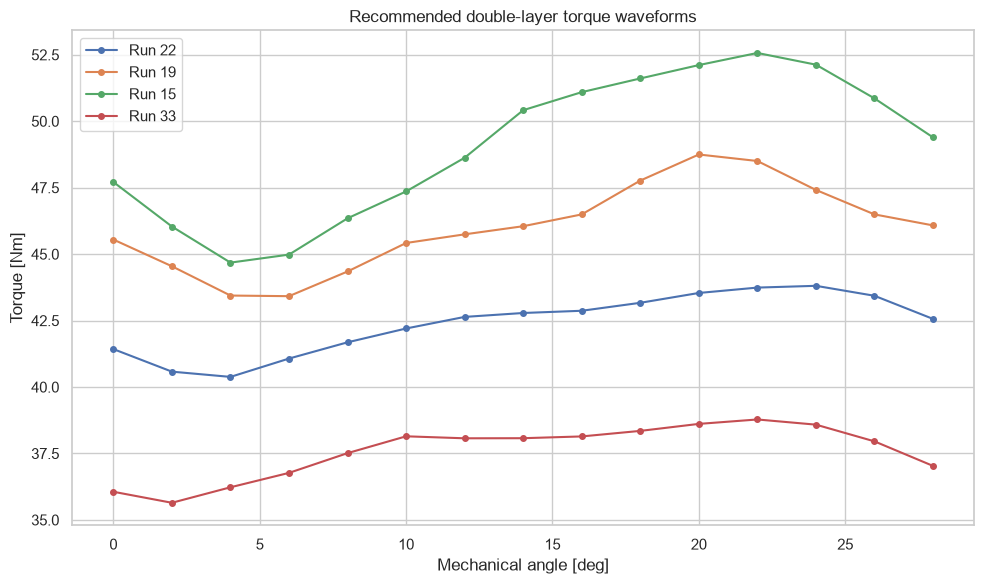

In [8]:
recommended = [22, 19, 15, 33]
fig, ax = plt.subplots(figsize=(10, 6))
for run in recommended:
    sweep = pd.read_csv(
        DOUBLE_DIR / f"run_{run:03d}" / "axis_shortedge_loaded_sweep.csv"
    )
    ax.plot(sweep.theta_deg, sweep.torque_Nm, "-o", ms=4, label=f"Run {run}")
ax.set(xlabel="Mechanical angle [deg]", ylabel="Torque [Nm]",
       title="Recommended double-layer torque waveforms")
ax.legend()
plt.tight_layout()
plt.show()

## 7. 다음 단계 추천

1. **Run 22, 19, 15**를 0–30°, 0.5° 간격으로 재해석한다.
2. 각 설계의 commutation offset을 30–40°에서 다시 최적화한다.
3. 저리플 목적이면 Run 22, 토크/자석비 목적이면 Run 19를 기준 형상으로 선택한다.
4. 검증된 기준점 주변에서 범위를 좁혀 surrogate 또는 NSGA-II를 진행한다.

현재 2° 간격에서는 토크 최대·최소를 놓칠 수 있으므로 0.5° 검증 전에는 Run 22와 Run 41처럼 가까운 설계의 순위를 확정하지 않는다.

# 8. DNN surrogate로 설계공간 10,000점 탐색

앞의 50점 파레토는 최종 최적해가 아니라 **DNN surrogate 학습용 FEMM DOE**다.

여기서는 GitHub의 `CCF_DNN_RANDOM1000_WORKFLOW.ipynb` 흐름을 현재 더블레이어 문제에 맞게 확장한다.

1. 실제 FEMM 50점으로 DNN 학습
2. 반복 교차검증으로 예측 성능 확인
3. 전체 설계범위에서 형상검사 통과 LHS 후보 10,000점 생성
4. 초기값이 다른 DNN 30개의 앙상블로 성능과 불확실성 예측
5. 평균토크 최대화·절대 리플 최소화 예측 파레토 추출
6. 최종 후보를 FEMM으로 재검증

> 아래 10,000점의 출력은 FEMM 결과가 아니라 DNN 예측값이다.

In [9]:
from scipy.stats import qmc
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import RepeatedKFold
from sklearn.neural_network import MLPRegressor

from generate_double_layer_ccf_50 import RANGES, evaluate

warnings.filterwarnings("ignore", category=ConvergenceWarning)
dnn_targets = [mean_col, ripple_col]
X_dnn = df[factors].to_numpy(dtype=float)
y_dnn = df[dnn_targets].to_numpy(dtype=float)

def make_dnn(seed):
    network = Pipeline([
        ("scale_x", StandardScaler()),
        ("dnn", MLPRegressor(
            hidden_layer_sizes=(32, 16, 8),
            activation="tanh",
            solver="lbfgs",
            alpha=1.0,
            max_iter=4000,
            random_state=seed,
        )),
    ])
    return TransformedTargetRegressor(
        regressor=network, transformer=StandardScaler()
    )

print("FEMM training samples:", len(X_dnn))
print("DNN inputs:", factors)
print("DNN outputs:", dnn_targets)

FEMM training samples: 50
DNN inputs: ['total_thickness_mm', 'inner_length_mm', 'v_angle_deg', 'layer_normal_gap_mm']
DNN outputs: ['loaded_torque_mean_Nm', 'loaded_torque_pkpk_Nm']


## 8.1 반복 교차검증

,Repeated-CV R2,Repeated-CV RMSE
Mean torque [Nm],0.9587,0.7476
Ripple pk-pk [Nm],0.9788,0.2303


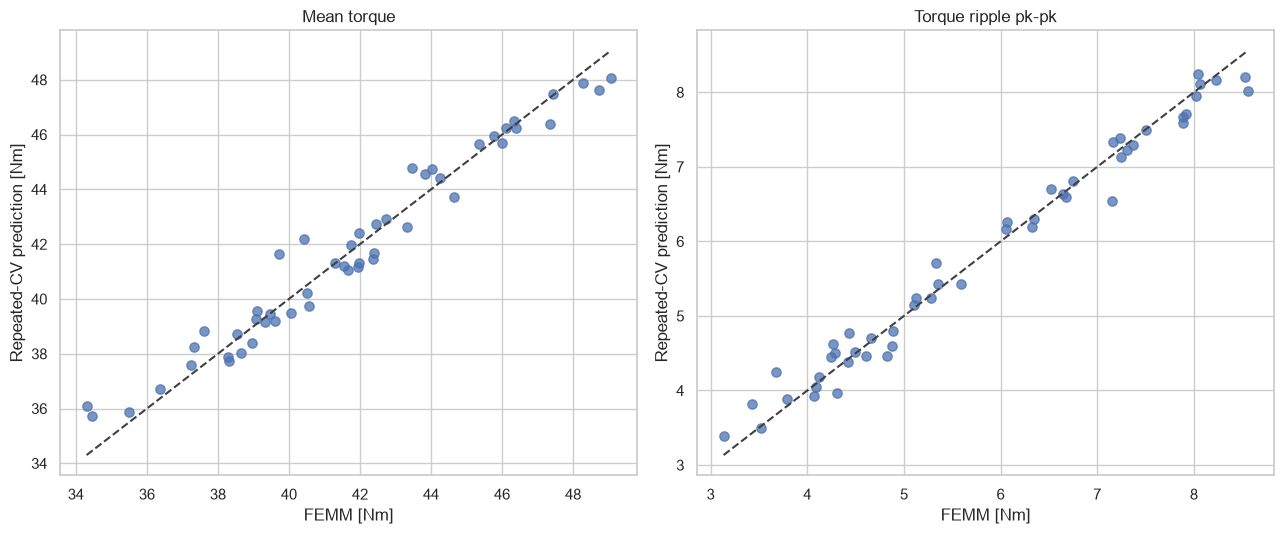

In [10]:
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=20260731)
pred_sum = np.zeros_like(y_dnn)
pred_count = np.zeros(len(y_dnn), dtype=int)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_dnn)):
    model = make_dnn(1000 + fold)
    model.fit(X_dnn[train_idx], y_dnn[train_idx])
    pred_sum[test_idx] += model.predict(X_dnn[test_idx])
    pred_count[test_idx] += 1

dnn_cv_pred = pred_sum / pred_count[:, None]
dnn_metrics = pd.DataFrame({
    "Repeated-CV R2": [
        r2_score(y_dnn[:, j], dnn_cv_pred[:, j]) for j in range(2)
    ],
    "Repeated-CV RMSE": [
        root_mean_squared_error(y_dnn[:, j], dnn_cv_pred[:, j])
        for j in range(2)
    ],
}, index=["Mean torque [Nm]", "Ripple pk-pk [Nm]"])
display(dnn_metrics)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for j, title in enumerate(["Mean torque", "Torque ripple pk-pk"]):
    axes[j].scatter(y_dnn[:, j], dnn_cv_pred[:, j], s=45, alpha=0.75)
    lo = min(y_dnn[:, j].min(), dnn_cv_pred[:, j].min())
    hi = max(y_dnn[:, j].max(), dnn_cv_pred[:, j].max())
    axes[j].plot([lo, hi], [lo, hi], "--", color="0.25")
    axes[j].set(
        xlabel="FEMM [Nm]", ylabel="Repeated-CV prediction [Nm]",
        title=title,
    )
plt.tight_layout()
plt.show()

교차검증 성능이 낮으면 10,000점을 생성해도 해상도만 높아질 뿐 정확도가 높아지는 것은 아니다.
따라서 파레토 후보의 앙상블 표준편차와 FEMM 재검증을 반드시 함께 사용한다.

## 8.2 형상검사 통과 LHS 후보 10,000점

In [11]:
n_candidates = 10_000
names = list(RANGES)
lower = np.array([RANGES[name][0] for name in names])
upper = np.array([RANGES[name][1] for name in names])
sampler = qmc.LatinHypercube(
    d=len(names), seed=20260731, optimization="random-cd"
)

candidate_cache = ROOT / "double_layer_dnn_candidates_10000.csv"
if candidate_cache.exists() and len(pd.read_csv(candidate_cache)) == n_candidates:
    candidates = pd.read_csv(candidate_cache)
    print(f"Loaded {len(candidates):,} cached geometry-valid candidates")
else:
    valid_rows = []
    tested = 0
    while len(valid_rows) < n_candidates:
        unit = sampler.random(12_000)
        batch = qmc.scale(unit, lower, upper)
        for values in batch:
            tested += 1
            row = evaluate(
                tested,
                {name: float(value) for name, value in zip(names, values)},
            )
            if row["geometry_status"] == "OK":
                valid_rows.append(row)
                if len(valid_rows) == n_candidates:
                    break
    candidates = pd.DataFrame(valid_rows)
    candidates["candidate"] = np.arange(1, len(candidates) + 1)
    print(f"Generated {tested:,} points; accepted {len(candidates):,}")
display(candidates[factors + [
    "outer_bridge_min_mm", "shaft_clearance_min_mm",
    "other_magnet_gap_min_mm"
]].describe().T)

Loaded 10,000 cached geometry-valid candidates


,count,mean,std,min,25%,50%,75%,max
total_thickness_mm,10000.0000,4.4858,0.5760,3.5000,3.9844,4.4803,4.9784,5.5000
inner_length_mm,10000.0000,15.6147,0.6525,14.5001,15.0520,15.6074,16.1642,16.7996
v_angle_deg,10000.0000,79.6723,5.6456,70.0001,74.7741,79.6246,84.4391,89.9975
layer_normal_gap_mm,10000.0000,1.2416,0.4321,0.5001,0.8670,1.2348,1.6152,2.0000
outer_bridge_min_mm,10000.0000,4.3571,0.4885,2.9705,4.0027,4.3476,4.7079,5.8566
shaft_clearance_min_mm,10000.0000,7.7755,0.7540,5.7985,7.2053,7.7531,8.3424,9.8469
other_magnet_gap_min_mm,10000.0000,0.6072,0.0048,0.5005,0.6075,0.6075,0.6075,0.6075


## 8.3 DNN 30개 앙상블 예측

In [12]:
n_ensemble = 30
candidate_X = candidates[factors].to_numpy(dtype=float)
ensemble = []
for seed in range(n_ensemble):
    model = make_dnn(2000 + seed)
    model.fit(X_dnn, y_dnn)
    ensemble.append(model.predict(candidate_X))

ensemble = np.stack(ensemble)
prediction = ensemble.mean(axis=0)
ensemble_std = ensemble.std(axis=0, ddof=1)
# Initialisation spread alone is too optimistic. Combine it with the
# out-of-fold residual scale measured above.
cv_rmse = dnn_metrics["Repeated-CV RMSE"].to_numpy(dtype=float)
uncertainty = np.sqrt(ensemble_std**2 + cv_rmse[None, :]**2)

candidates["pred_mean_torque_Nm"] = prediction[:, 0]
candidates["pred_ripple_pkpk_Nm"] = prediction[:, 1]
candidates["unc_mean_torque_Nm"] = uncertainty[:, 0]
candidates["unc_ripple_pkpk_Nm"] = uncertainty[:, 1]
candidates["ensemble_std_mean_torque_Nm"] = ensemble_std[:, 0]
candidates["ensemble_std_ripple_pkpk_Nm"] = ensemble_std[:, 1]
candidates["conservative_mean_Nm"] = (
    candidates.pred_mean_torque_Nm - candidates.unc_mean_torque_Nm
)
candidates["conservative_ripple_Nm"] = (
    candidates.pred_ripple_pkpk_Nm + candidates.unc_ripple_pkpk_Nm
)

def fast_pareto(frame, mean_name, ripple_name):
    ordered = frame.sort_values(
        [mean_name, ripple_name], ascending=[False, True]
    )
    best_ripple = np.inf
    selected = []
    for idx, row in ordered.iterrows():
        if row[ripple_name] < best_ripple:
            selected.append(idx)
            best_ripple = row[ripple_name]
    mask = pd.Series(False, index=frame.index)
    mask.loc[selected] = True
    return mask

candidates["predicted_pareto"] = fast_pareto(
    candidates, "pred_mean_torque_Nm", "pred_ripple_pkpk_Nm"
)
candidates["conservative_pareto"] = fast_pareto(
    candidates, "conservative_mean_Nm", "conservative_ripple_Nm"
)
pred_front = candidates[candidates.predicted_pareto].copy()
print("Predicted Pareto:", len(pred_front))
print("Conservative Pareto:", int(candidates.conservative_pareto.sum()))

Predicted Pareto: 78
Conservative Pareto: 78


## 8.4 촘촘한 예측 파레토

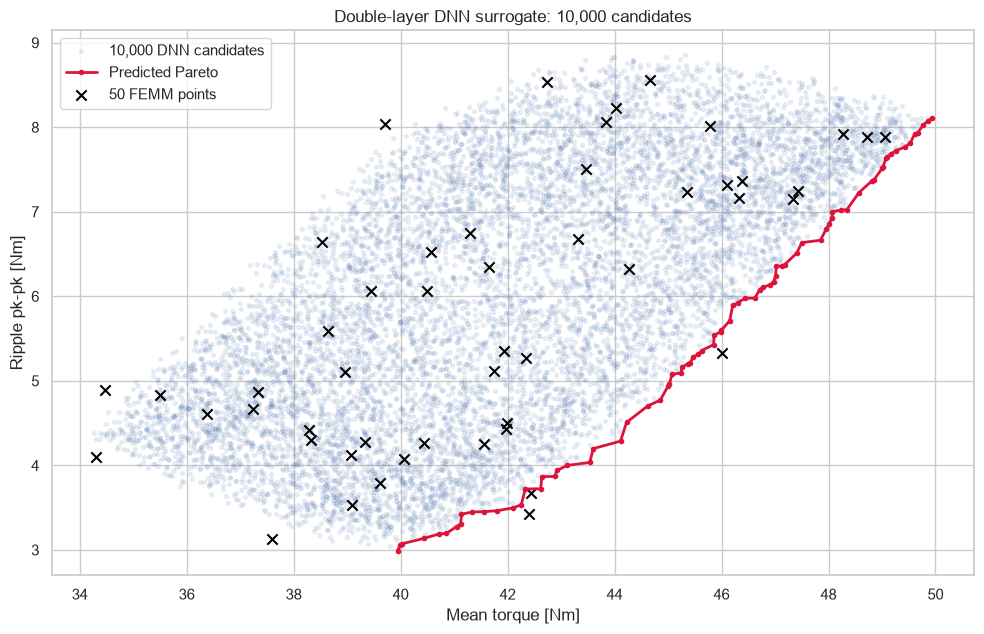

In [13]:
front_sorted = pred_front.sort_values("pred_mean_torque_Nm")
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(
    candidates.pred_mean_torque_Nm,
    candidates.pred_ripple_pkpk_Nm,
    s=8, alpha=0.10, label="10,000 DNN candidates",
)
ax.plot(
    front_sorted.pred_mean_torque_Nm,
    front_sorted.pred_ripple_pkpk_Nm,
    "-o", color="crimson", lw=2, ms=3, label="Predicted Pareto",
)
ax.scatter(
    df[mean_col], df[ripple_col],
    marker="x", color="black", s=55, label="50 FEMM points",
)
ax.set(
    xlabel="Mean torque [Nm]",
    ylabel="Ripple pk-pk [Nm]",
    title="Double-layer DNN surrogate: 10,000 candidates",
)
ax.legend()
plt.tight_layout()
plt.show()

## 8.5 균형 최적점과 FEMM 재검증 후보

In [14]:
# 파레토 내부에서 ideal point까지 정규화 거리
torque_span = (
    pred_front.pred_mean_torque_Nm.max()
    - pred_front.pred_mean_torque_Nm.min()
)
ripple_span = (
    pred_front.pred_ripple_pkpk_Nm.max()
    - pred_front.pred_ripple_pkpk_Nm.min()
)
pred_front["torque_loss_norm"] = (
    pred_front.pred_mean_torque_Nm.max()
    - pred_front.pred_mean_torque_Nm
) / torque_span
pred_front["ripple_loss_norm"] = (
    pred_front.pred_ripple_pkpk_Nm
    - pred_front.pred_ripple_pkpk_Nm.min()
) / ripple_span
pred_front["ideal_distance"] = np.hypot(
    pred_front.torque_loss_norm, pred_front.ripple_loss_norm
)

# FEMM 검증 후보: knee 3개 + 저리플 끝점 + 고토크 끝점
knee = pred_front.nsmallest(3, "ideal_distance")
low_ripple = pred_front.nsmallest(1, "pred_ripple_pkpk_Nm")
high_torque = pred_front.nlargest(1, "pred_mean_torque_Nm")
validation = (
    pd.concat([knee, low_ripple, high_torque])
    .drop_duplicates("candidate")
    .sort_values("ideal_distance")
)

result_cols = [
    "candidate", *factors, "magnet_center_offset_deg",
    "outer_bridge_min_mm", "other_magnet_gap_min_mm",
    "pred_mean_torque_Nm", "unc_mean_torque_Nm",
    "pred_ripple_pkpk_Nm", "unc_ripple_pkpk_Nm",
    "conservative_mean_Nm", "conservative_ripple_Nm",
    "ideal_distance",
]
print("FEMM 재검증 우선 후보")
display(validation[result_cols].set_index("candidate"))

FEMM 재검증 우선 후보


,total_thickness_mm,inner_length_mm,v_angle_deg,layer_normal_gap_mm,magnet_center_offset_deg,outer_bridge_min_mm,other_magnet_gap_min_mm,pred_mean_torque_Nm,unc_mean_torque_Nm,pred_ripple_pkpk_Nm,unc_ripple_pkpk_Nm,conservative_mean_Nm,conservative_ripple_Nm,ideal_distance
candidate,,,,,,,,,,,,,,
8887,5.4788,16.7420,83.6732,0.9791,24.2475,4.0050,0.6075,44.8547,0.7561,4.7711,0.2383,44.0987,5.0094,0.6159
4152,5.4589,16.6601,83.1162,0.8811,24.0590,4.0384,0.6075,45.0009,0.7554,4.9397,0.2374,44.2455,5.1770,0.6234
4288,5.1792,16.7730,81.6579,0.7498,24.0649,4.0405,0.6075,45.2464,0.7567,5.0948,0.2376,44.4898,5.3324,0.6237
8945,3.6752,16.7539,89.2042,0.5291,24.9993,5.1580,0.6075,39.9412,0.7537,2.9926,0.2366,39.1875,3.2292,1.0000
3319,5.4971,16.7572,70.2209,1.2527,21.4933,3.0937,0.6075,49.9367,0.7530,8.1090,0.2349,49.1837,8.3440,1.0000


## 8.6 예측 결과 저장

In [15]:
candidate_csv = ROOT / "double_layer_dnn_candidates_10000.csv"
pareto_csv = ROOT / "double_layer_dnn_predicted_pareto.csv"
validation_csv = ROOT / "double_layer_dnn_femm_validation_candidates.csv"

candidates.to_csv(candidate_csv, index=False)
pred_front.sort_values("ideal_distance").to_csv(pareto_csv, index=False)
validation[result_cols].to_csv(validation_csv, index=False)

print("Saved:", candidate_csv)
print("Saved:", pareto_csv)
print("Saved:", validation_csv)

Saved: c:\Users\139\Documents\pyFEMM 2\double_layer_dnn_candidates_10000.csv
Saved: c:\Users\139\Documents\pyFEMM 2\double_layer_dnn_predicted_pareto.csv
Saved: c:\Users\139\Documents\pyFEMM 2\double_layer_dnn_femm_validation_candidates.csv


## 9. 이 분석에서 말하는 최적점

- 50개 FEMM 파레토는 **관측된 최선점**
- 10,000개 DNN 파레토는 **surrogate가 제안한 최적 후보**
- 최종 최적점은 **DNN 후보를 FEMM으로 재해석한 뒤** 확정

따라서 다음 단계는 `double_layer_dnn_femm_validation_candidates.csv`의 후보를
0–30°, 0.5° 간격과 commutation offset 재탐색 조건으로 FEMM 검증하는 것이다.
검증 결과를 기존 50점에 추가해 DNN을 재학습하면 순차적으로 최적점 신뢰도가 높아진다.

# 10. 자석 사용량 최소화–평균토크 최대화 파레토

이번 파레토의 목적함수는 다음 두 개다.

- **회전자 전체 자석 사용량 최소화**
- **DNN 예측 평균토크 최대화**

안쪽 자석 한 장의 두께는 총 두께의 1/2이고, 바깥 자석은 안쪽 대비 길이와 두께가 각각 80%다.
따라서 한쪽 V-wing의 자석 단면적은 다음과 같다.

\[
A_{wing} =
\frac{T}{2}L +
\left(0.8\frac{T}{2}\right)(0.8L)
=0.82TL
\]

4극 × 좌우 2개 wing이므로 회전자 전체 자석 단면적은 \(8\times0.82TL\)이다.
모델 적층 길이를 곱해 자석 체적도 함께 계산한다.

In [16]:
import generate_v_ipm_motor as motor_base

MAGNET_FACTOR = 8 * (0.5 + 0.5 * 0.8 * 0.8)
candidates["magnet_area_total_mm2"] = (
    MAGNET_FACTOR
    * candidates["total_thickness_mm"]
    * candidates["inner_length_mm"]
)
candidates["magnet_volume_total_cm3"] = (
    candidates["magnet_area_total_mm2"] * motor_base.DEPTH / 1000
)
candidates["pred_torque_per_magnet_cm3"] = (
    candidates["pred_mean_torque_Nm"]
    / candidates["magnet_volume_total_cm3"]
)

def magnet_torque_pareto(frame):
    # Torque descending: retain each new record-low magnet volume.
    ordered = frame.sort_values(
        ["pred_mean_torque_Nm", "magnet_volume_total_cm3"],
        ascending=[False, True],
    )
    best_volume = np.inf
    selected = []
    for idx, row in ordered.iterrows():
        if row["magnet_volume_total_cm3"] < best_volume:
            selected.append(idx)
            best_volume = row["magnet_volume_total_cm3"]
    mask = pd.Series(False, index=frame.index)
    mask.loc[selected] = True
    return mask

candidates["magnet_torque_pareto"] = magnet_torque_pareto(candidates)
magnet_front = candidates[candidates.magnet_torque_pareto].copy()
magnet_front = magnet_front.sort_values("magnet_volume_total_cm3")
print(f"Magnet–torque Pareto designs: {len(magnet_front)} / {len(candidates)}")
print(f"Motor stack depth: {motor_base.DEPTH:g} mm")

Magnet–torque Pareto designs: 53 / 10000
Motor stack depth: 150 mm


## 10.1 자석 체적–평균토크 파레토

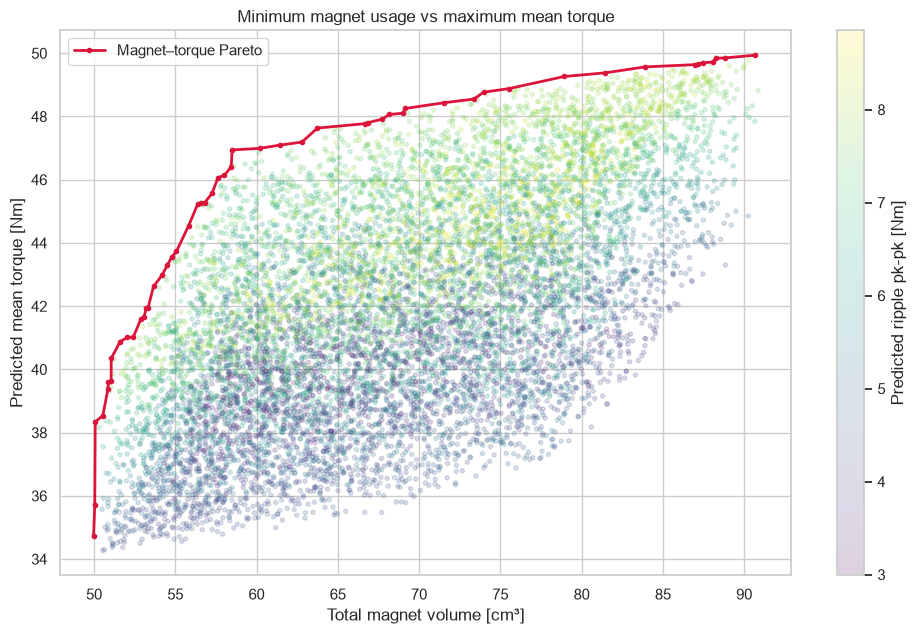

In [17]:
fig, ax = plt.subplots(figsize=(10, 6.5))
scatter = ax.scatter(
    candidates["magnet_volume_total_cm3"],
    candidates["pred_mean_torque_Nm"],
    c=candidates["pred_ripple_pkpk_Nm"],
    cmap="viridis", s=9, alpha=0.18,
)
ax.plot(
    magnet_front["magnet_volume_total_cm3"],
    magnet_front["pred_mean_torque_Nm"],
    "-o", color="crimson", lw=2, ms=3,
    label="Magnet–torque Pareto",
)
ax.set(
    xlabel="Total magnet volume [cm³]",
    ylabel="Predicted mean torque [Nm]",
    title="Minimum magnet usage vs maximum mean torque",
)
fig.colorbar(scatter, ax=ax, label="Predicted ripple pk-pk [Nm]")
ax.legend()
plt.tight_layout()
plt.show()

색은 예측 절대 리플이다. 자석–토크 파레토에 포함되더라도 리플이 지나치게 크면 실제 추천 후보에서는 제외할 수 있다.

## 10.2 균형점과 FEMM 검증 후보

In [18]:
volume_span = (
    magnet_front.magnet_volume_total_cm3.max()
    - magnet_front.magnet_volume_total_cm3.min()
)
torque_span = (
    magnet_front.pred_mean_torque_Nm.max()
    - magnet_front.pred_mean_torque_Nm.min()
)
magnet_front["volume_loss_norm"] = (
    magnet_front.magnet_volume_total_cm3
    - magnet_front.magnet_volume_total_cm3.min()
) / volume_span
magnet_front["torque_loss_norm"] = (
    magnet_front.pred_mean_torque_Nm.max()
    - magnet_front.pred_mean_torque_Nm
) / torque_span
magnet_front["magnet_torque_ideal_distance"] = np.hypot(
    magnet_front.volume_loss_norm,
    magnet_front.torque_loss_norm,
)

# 기본 knee 후보와 리플 6 Nm 이하인 실용 후보를 각각 확인한다.
magnet_knee = magnet_front.nsmallest(10, "magnet_torque_ideal_distance")
practical_front = magnet_front[
    magnet_front.pred_ripple_pkpk_Nm <= 6.0
].copy()
practical_knee = practical_front.nsmallest(
    10, "magnet_torque_ideal_distance"
)

magnet_cols = [
    "candidate", *factors,
    "magnet_volume_total_cm3",
    "pred_mean_torque_Nm", "unc_mean_torque_Nm",
    "pred_ripple_pkpk_Nm", "unc_ripple_pkpk_Nm",
    "pred_torque_per_magnet_cm3",
    "magnet_torque_ideal_distance",
]
print("자석량–토크 순수 파레토 균형 후보")
display(magnet_knee[magnet_cols].set_index("candidate"))
print("리플 6 Nm 이하 조건을 만족하는 균형 후보")
display(practical_knee[magnet_cols].set_index("candidate"))

자석량–토크 순수 파레토 균형 후보


,total_thickness_mm,inner_length_mm,v_angle_deg,layer_normal_gap_mm,magnet_volume_total_cm3,pred_mean_torque_Nm,unc_mean_torque_Nm,pred_ripple_pkpk_Nm,unc_ripple_pkpk_Nm,pred_torque_per_magnet_cm3,magnet_torque_ideal_distance
candidate,,,,,,,,,,,
8294,3.5549,16.7233,70.0811,1.5993,58.4980,46.9404,0.7499,7.4562,0.2314,0.8024,0.2878
7604,3.5874,16.5546,70.2543,1.2011,58.4382,46.4098,0.7498,7.3586,0.2324,0.7942,0.3117
9875,3.5296,16.5922,71.0609,1.2490,57.6269,46.0659,0.7492,7.1401,0.2321,0.7994,0.3167
1769,3.6422,16.7950,70.6129,1.1160,60.1918,46.9917,0.7488,7.1910,0.2319,0.7807,0.3173
1969,3.5791,16.4744,70.4479,1.3669,58.0200,46.1357,0.7497,7.4099,0.2317,0.7952,0.3189
8585,3.7540,16.6326,70.5416,1.9004,61.4396,47.0941,0.7515,7.6067,0.2324,0.7665,0.3384
8931,3.5441,16.4198,70.9896,1.0632,57.2620,45.5722,0.7505,7.1621,0.2343,0.7959,0.3385
1571,3.5215,16.3290,70.6294,0.8038,56.5826,45.2734,0.7544,7.1553,0.2393,0.8001,0.3472
3065,3.5196,16.2797,70.2450,0.7521,56.3818,45.2340,0.7564,7.2376,0.2409,0.8023,0.3473


리플 6 Nm 이하 조건을 만족하는 균형 후보


,total_thickness_mm,inner_length_mm,v_angle_deg,layer_normal_gap_mm,magnet_volume_total_cm3,pred_mean_torque_Nm,unc_mean_torque_Nm,pred_ripple_pkpk_Nm,unc_ripple_pkpk_Nm,pred_torque_per_magnet_cm3,magnet_torque_ideal_distance
candidate,,,,,,,,,,,
5174,3.5020,14.5224,82.9839,0.9798,50.0434,35.7175,0.7514,5.3251,0.2345,0.7137,0.9357
7005,3.5003,14.5089,87.6413,0.7978,49.9733,34.7399,0.7519,4.6339,0.2327,0.6952,1.0000


## 10.3 결과 저장

In [ ]:
magnet_front_csv = ROOT / "double_layer_dnn_magnet_torque_pareto.csv"
magnet_validation_csv = (
    ROOT / "double_layer_dnn_magnet_torque_validation_candidates.csv"
)
magnet_front.sort_values(
    "magnet_torque_ideal_distance"
).to_csv(magnet_front_csv, index=False)
practical_knee[magnet_cols].to_csv(magnet_validation_csv, index=False)
print("Saved:", magnet_front_csv)
print("Saved:", magnet_validation_csv)

Saved: c:\Users\139\Documents\pyFEMM 2\double_layer_dnn_magnet_torque_pareto.csv
Saved: c:\Users\139\Documents\pyFEMM 2\double_layer_dnn_magnet_torque_validation_candidates.csv


: 

## 10.4 해석 기준

- 순수 파레토는 자석량과 평균토크만 판단하므로 리플이 큰 고토크 형상도 포함된다.
- 실제 FEMM 검증 우선순위는 `리플 6 Nm 이하` 표의 상위 후보가 더 적절하다.
- 최종 경제성 비교에는 자석 체적뿐 아니라 철손, 역기전력, 감자 여유와 기계적 브리지 강도도 추가해야 한다.